In [1]:
import pandas as pd

# def load_data(train_data_path, target_data_path, test_data_path):
#     X_train = pd.read_csv(train_data_path, index_col='id')
#     X_train.index = X_train.index.astype(int)
#     y_train = pd.read_csv(target_data_path, index_col='id')
#     y_train.index = y_train.index.astype(int)
#     X_test = pd.read_csv(test_data_path, index_col='id')
#     X_test.index = X_test.index.astype(int)
#     return X_train, y_train, X_test

X_train_df = pd.read_csv("data/X_train.csv", index_col='id')
y_train_df = pd.read_csv("data/y_train.csv", index_col='id')

In [2]:
# Replace all NaN values with zero
X_train_df = X_train_df.fillna(0)
#y_train_df['y'].value_counts()

In [3]:
from imblearn.over_sampling import RandomOverSampler

#balance classes and only keep first 1000 features
#ros = RandomOverSampler(sampling_strategy={0: 3030, 1:3030, 2:3030, 3:3030})
#X_train_df, y_train_df = ros.fit_resample(X_train_df, y_train_df)

X_train_df  = X_train_df.iloc[:, :2000]
X_train_df.shape, X_train_df

((5117, 2000),
        x0   x1   x2   x3   x4   x5   x6   x7   x8   x9  ...  x1990  x1991  \
 id                                                      ...                 
 0     -13   -9   -6   -4    0    2    6   12   23   35  ...    -59    -58   
 1     -34  110  249  390  527  639  721  777  823  845  ...    448    447   
 2     -34  -36  -37  -39  -41  -42  -44  -46  -48  -51  ...    -13     -9   
 3     292  298  303  310  320  336  354  377  405  419  ...   -203   -196   
 4     157  179  195  210  217  222  226  228  231  233  ...    -83    -80   
 ...   ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...    ...    ...   
 5112 -247 -271 -285 -303 -334 -376 -413 -432 -443 -451  ...   1132   1308   
 5113   62   62   61   61   61   61   61   61   61   62  ...    -86    -89   
 5114  -95 -110 -124 -131 -126 -114  -95  -67  -42  -23  ...   -244   -223   
 5115  -50  -48  -45  -42  -38  -35  -32  -30  -28  -26  ...    106     98   
 5116   66   65   63   62   65   72   80   84   8

In [4]:
#weights for the random sampler
weights = 1 / y_train_df.value_counts()
weights

y
0    0.000330
2    0.000678
1    0.002257
3    0.005882
dtype: float64

In [6]:
#create dataset and trainloader
import torch
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split

#split train and test
X_train = X_train_df.to_numpy().reshape(5117, 1, 2000)
y_train = y_train_df.to_numpy()
X_train, X_test, y_train, y_test = train_test_split(
    X_train, y_train, test_size=0.2,
)

#transfer data to gpu
X_train, y_train = torch.Tensor(X_train), torch.Tensor(y_train)
X_test, y_test = torch.Tensor(X_test), torch.Tensor(y_test)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)



dataset_train = TensorDataset(X_train, y_train)

# Create a DataLoader
batch_size = 64
sampler = WeightedRandomSampler(weights=weights, num_samples=len(dataset_train))
train_loader = DataLoader(dataset_train, batch_size=batch_size, sampler=sampler)


X_train, y_train

(tensor([[[ 350.,  337.,  297.,  ...,  222.,  220.,  217.]],
 
         [[ -55.,  -49.,  -42.,  ...,   64.,   72.,   79.]],
 
         [[ -49.,  -49.,  -50.,  ...,   20.,   20.,   21.]],
 
         ...,
 
         [[ 152.,  151.,  149.,  ..., -183., -237., -303.]],
 
         [[ 451.,  424.,  312.,  ..., -216., -213., -202.]],
 
         [[  90.,  -41., -193.,  ..., -805., -854., -940.]]], device='cuda:0'),
 tensor([[0.],
         [0.],
         [2.],
         ...,
         [1.],
         [2.],
         [3.]], device='cuda:0'))

In [10]:
import torch.nn as nn

import model_domi as md

model = nn.Sequential(
    md.ConvBNReLU_0(),
    md.LFEM_i(32, 16),
    #md.LFEM_i(48, 72),
    #md.LFEM_i(72, 108),
    # LFEM_i(128, 256),
    # LFEM_i(256, 256),
    md.GRUDense(input_size=248),
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

Sequential(
  (0): ConvBNReLU_0(
    (conv): Conv1d(1, 32, kernel_size=(9,), stride=(1,))
    (bn): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
  )
  (1): LFEM_i(
    (conv1): Conv1d(32, 16, kernel_size=(3,), stride=(2,))
    (conv2): Conv1d(16, 16, kernel_size=(3,), stride=(2,))
    (bn2): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu2): ReLU()
    (maxpool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (2): GRUDense(
    (dropout): Dropout(p=0.2, inplace=False)
    (gru): GRU(248, 30, batch_first=True)
    (dense): Linear(in_features=30, out_features=4, bias=True)
  )
)

In [8]:
model(X_train).shape

torch.Size([4093, 4])

In [11]:
#define loss and optimizer

import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

In [12]:
import model_domi as md

for epoch in range(100):  # loop over the dataset multiple times

    running_loss = 0.0
    for i, data in enumerate(train_loader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data
        labels = labels[:, 0].type(torch.int64)

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % 10 == 9:    # print every 10 minibatches
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 10:.3f}')
            print(f'[{epoch + 1}, {i + 1:5d}] test_loss: {md.compute_f1_loss(model, X_test, y_test)}')
            running_loss = 0.0

print('Finished Training')

[1,    10] loss: 0.799
[1,    10] test_loss: 0.58984375
[1,    20] loss: 0.367
[1,    20] test_loss: 0.58984375
[1,    30] loss: 0.202
[1,    30] test_loss: 0.5888671875
[1,    40] loss: 0.128
[1,    40] test_loss: 0.5888671875
[1,    50] loss: 0.085
[1,    50] test_loss: 0.5888671875
[1,    60] loss: 0.064
[1,    60] test_loss: 0.5869140625
[2,    10] loss: 0.044
[2,    10] test_loss: 0.587890625
[2,    20] loss: 0.037
[2,    20] test_loss: 0.587890625
[2,    30] loss: 0.031
[2,    30] test_loss: 0.5869140625
[2,    40] loss: 0.026
[2,    40] test_loss: 0.5869140625
[2,    50] loss: 0.023
[2,    50] test_loss: 0.5869140625
[2,    60] loss: 0.021
[2,    60] test_loss: 0.5859375
[3,    10] loss: 0.018
[3,    10] test_loss: 0.5869140625
[3,    20] loss: 0.017
[3,    20] test_loss: 0.5869140625
[3,    30] loss: 0.015
[3,    30] test_loss: 0.5888671875
[3,    40] loss: 0.014
[3,    40] test_loss: 0.5869140625
[3,    50] loss: 0.012
[3,    50] test_loss: 0.587890625
[3,    60] loss: 0.012
[

KeyboardInterrupt: 

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim

# Example: Random model predictions and ground truth labels
predictions = torch.randn(64, 10)  # 64 samples, 10 classes
labels = torch.randint(0, 10, (64,))  # Random labels between 0 and 9

# Define CrossEntropyLoss
criterion = nn.CrossEntropyLoss()

# Calculate the loss
loss = criterion(predictions, labels)

In [ ]:
import numpy as np
import torch

# Create a NumPy array
numpy_array = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])

# Convert NumPy array to PyTorch tensor using torch.from_numpy()
tensor_from_numpy = torch.from_numpy(numpy_array)

# Convert NumPy array to PyTorch tensor using torch.Tensor()
tensor_from_tensor = torch.Tensor(numpy_array)

print("NumPy Array:")
print(numpy_array)

print("\nPyTorch Tensor (from torch.from_numpy()):")
print(tensor_from_numpy)

print("\nPyTorch Tensor (from torch.Tensor()):")
print(tensor_from_tensor)




NumPy Array:
[[1 2 3]
 [4 5 6]
 [7 8 9]]

PyTorch Tensor (from torch.from_numpy()):
tensor([[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]], dtype=torch.int32)

PyTorch Tensor (from torch.Tensor()):
tensor([[1., 2., 3.],
        [4., 5., 6.],
        [7., 8., 9.]])


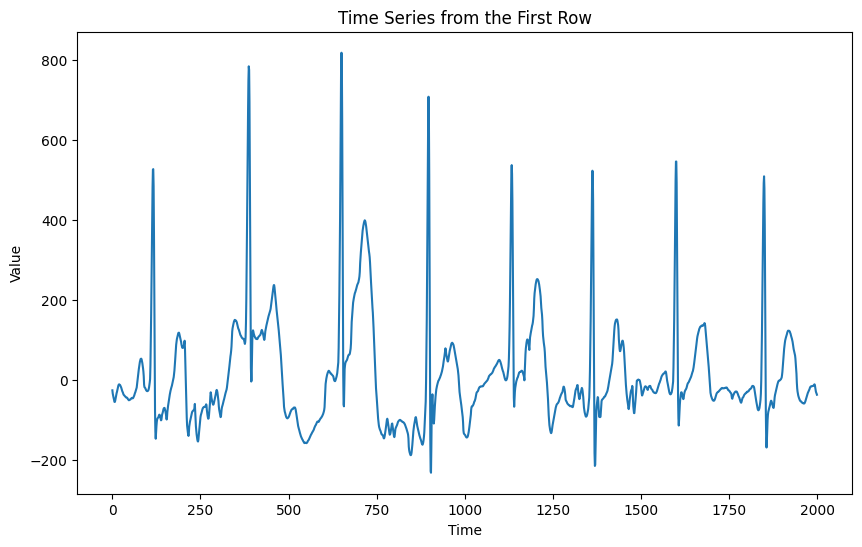

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(2000), X_train_df.iloc[500, 0:2000], linestyle='-')
plt.title('Time Series from the First Row')
plt.xlabel('Time')
plt.ylabel('Value')
plt.show()